# Praktikum 3 - Klasifikasi
___
Nama: Arief Purnama Muharram<br>
NIM: 23521013

## Step 0: Prerequisites
___

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


print('Pandas version:', pd.__version__)
print('Seaborn version:', sns.__version__)

Pandas version: 1.3.5
Seaborn version: 0.11.2


## Step 1: Load Dataset
___

In [2]:
df_train = pd.read_csv("../input/praktikum-3-dsai-klasifikasi/data_train.csv")
df_test = pd.read_csv("../input/praktikum-3-dsai-klasifikasi/data_test.csv")
df_validate = pd.read_csv("../input/praktikum-3-dsai-klasifikasi/data_validate.csv")

In [3]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         266 non-null    int64  
 1   Age        266 non-null    int64  
 2   Gender     266 non-null    object 
 3   Employed   266 non-null    object 
 4   Graduate   265 non-null    float64
 5   Work Exp   266 non-null    int64  
 6   Salary     266 non-null    float64
 7   Distance   266 non-null    float64
 8   Licence    266 non-null    int64  
 9   Transport  266 non-null    object 
dtypes: float64(3), int64(4), object(3)
memory usage: 20.9+ KB


In [4]:
df_train.describe()

,ID,Age,Graduate,Work Exp,Salary,Distance,Licence
count,266.000000,266.000000,265.000000,266.000000,266.000000,266.000000,266.000000
mean,132.500000,27.721805,0.241509,6.319549,16.259774,11.383459,0.229323
std,76.931788,4.513884,0.428808,5.171708,10.575340,3.703363,0.421190
min,0.000000,18.000000,0.000000,0.000000,6.700000,3.200000,0.000000
25%,66.250000,25.000000,0.000000,3.000000,9.800000,8.800000,0.000000
50%,132.500000,27.000000,0.000000,5.000000,13.550000,11.000000,0.000000
75%,198.750000,30.000000,0.000000,8.000000,15.675000,13.600000,0.000000
max,265.000000,42.000000,1.000000,22.000000,57.000000,22.800000,1.000000


In [5]:
for attribute in df_train:
    if attribute != 'ID':
        print(attribute, ':', df_train[attribute].unique(), '\n')

Age : [35 29 25 28 24 26 21 27 38 33 30 22 34 23 20 42 40 19 31 37 32 39 36 18] 

Gender : ['Female' 'Male'] 

Employed : ['Yes' 'No'] 

Graduate : [ 0.  1. nan] 

Work Exp : [15  7  3  5  1  2 18 14  8  4  6  0  9 16 22 19 11 20 21 13 12 10 17] 

Salary : [37.  14.6  9.9 13.6  8.8  9.8 12.5 45.  15.   9.6 33.  21.8 12.8 10.5
  8.5  6.8 13.5 21.7 23.   9.5 34.9 38.  10.9  8.9 21.6  8.4 14.7 55.
 10.6  7.6 44.   8.6 13.9  7.5 10.7 10.8 11.5 51.  16.9 14.3 12.7 28.8
 47.  12.9 18.8 15.8 14.9 34.  17.8 17.  15.5  7.7 12.3 15.6 11.8 11.6
 57.  20.8 13.  15.9 39.9 42.9 23.9 16.5 41.9  7.8 43.  13.4 13.7 40.9
 38.9  8.7 13.8 24.9  7.9  9.  20.7 41.   6.9  7.  10.  18.9 11.7 39.
 14.8 28.7 16.7 14.4  6.7  8.  36.9 46.  12.4 15.7 42.  23.8 48.  12.6
 54.  35. ] 

Distance : [13.5  9.2  7.7 14.6  7.9 12.6 17.7 11.   9.3 18.1 19.   8.1 17.3 15.5
 13.4 17.2 14.2  8.9  8.  14.5  5.2 11.3  7.3 16.3  6.3 12.2 17.9 10.7
 21.3  9.  16.8  6.8 12.9 12.3 19.8 10.   9.5 10.5  6.4 12.7 12.8 11.7
  9.1  5.3

In [6]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89 entries, 0 to 88
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ID        89 non-null     int64  
 1   Age       89 non-null     int64  
 2   Gender    89 non-null     object 
 3   Employed  89 non-null     object 
 4   Graduate  89 non-null     float64
 5   Work Exp  89 non-null     int64  
 6   Salary    89 non-null     float64
 7   Distance  89 non-null     float64
 8   Licence   89 non-null     int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.4+ KB


In [7]:
df_validate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89 entries, 0 to 88
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         89 non-null     int64  
 1   Age        89 non-null     int64  
 2   Gender     89 non-null     object 
 3   Employed   89 non-null     object 
 4   Graduate   89 non-null     float64
 5   Work Exp   89 non-null     int64  
 6   Salary     89 non-null     float64
 7   Distance   89 non-null     float64
 8   Licence    89 non-null     int64  
 9   Transport  89 non-null     object 
dtypes: float64(3), int64(4), object(3)
memory usage: 7.1+ KB


## Step 2: Data Exploration
___

### 2.1: Print sample dataset

In [8]:
df_train.head(3)

,ID,Age,Gender,Employed,Graduate,Work Exp,Salary,Distance,Licence,Transport
0,0,35,Female,Yes,0.0,15,37.0,13.5,1,Private Transport
1,1,29,Female,No,0.0,7,14.6,9.2,0,Other
2,2,29,Female,No,0.0,7,14.6,7.7,0,Public Transport


### 2.2: Check for null data

In [9]:
df_train.isnull().any()

ID           False
Age          False
Gender       False
Employed     False
Graduate      True
Work Exp     False
Salary       False
Distance     False
Licence      False
Transport    False
dtype: bool

Found null data on 'Graduate' attribute. Inspect unique value of 'Graduate' attribute.

In [10]:
df_train['Graduate'].unique()

array([ 0.,  1., nan])

Inspect number of *null* data on 'Graduate' attribute

In [11]:
df_train['Graduate'].isnull().sum()

1

Because only one row of data that have null on its 'Graduate' attribute, prefer to drop the row. Dropping just one data doesn't affect the majority data.

In [12]:
df_train = df_train.dropna(how='any')

In [13]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 265 entries, 0 to 265
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         265 non-null    int64  
 1   Age        265 non-null    int64  
 2   Gender     265 non-null    object 
 3   Employed   265 non-null    object 
 4   Graduate   265 non-null    float64
 5   Work Exp   265 non-null    int64  
 6   Salary     265 non-null    float64
 7   Distance   265 non-null    float64
 8   Licence    265 non-null    int64  
 9   Transport  265 non-null    object 
dtypes: float64(3), int64(4), object(3)
memory usage: 22.8+ KB


### 2.2: Check for duplicate data

In [14]:
df_train.duplicated().sum()

0

No duplicate data! Proceed to the next steps.

### 2.3: Data visualization

#### Gender Distribution

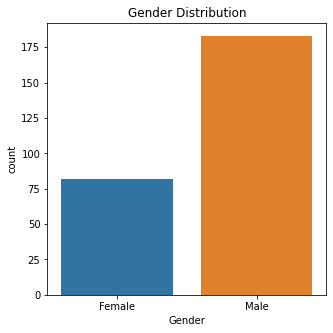

In [15]:
plt.figure(figsize=(5,5))
sns.countplot(data=df_train, x='Gender')
plt.title('Gender Distribution')
plt.show()

Male data is almost twice as much as female category.

#### Age Distribution

<Figure size 1080x360 with 0 Axes>

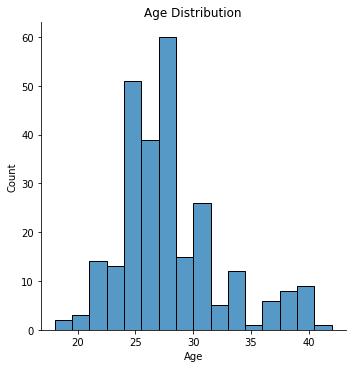

In [16]:
plt.figure(figsize=(15,5))
sns.displot(data=df_train, x='Age')
plt.title('Age Distribution')
plt.show()

Not normally distributed, but still ok.

#### Transportation Type Distribution

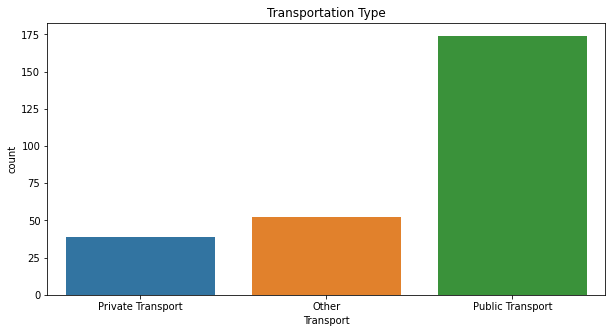

In [17]:
plt.figure(figsize=(10,5))
sns.countplot(data=df_train, x='Transport')
plt.title('Transportation Type')
plt.show()

Imbalance dataset. The number of public transport category is several times larger than private and other transport category.

## Step 3: Feature Engineering
___

### Gender

Convert 'Gender' attribute into its numerical representation.

In [18]:
dict_gender = {
    'Male': 1,
    'Female': 2
}

# Convert for all df_train, df_test, and df_validate
df_train['Gender'] = df_train['Gender'].apply(lambda x: dict_gender[x])
df_test['Gender'] = df_test['Gender'].apply(lambda x: dict_gender[x])
df_validate['Gender'] = df_validate['Gender'].apply(lambda x: dict_gender[x])

# Try to print the unique value
df_train['Gender'].unique()

array([2, 1])

### Employed

Convert 'Employed' attribute into its numerical representation.

In [19]:
dict_employed = {
    'Yes': 1,
    'No': 0
}

# Convert for all df_train, df_test, and df_validate
df_train['Employed'] = df_train['Employed'].apply(lambda x: dict_employed[x])
df_test['Employed'] = df_test['Employed'].apply(lambda x: dict_employed[x])
df_validate['Employed'] = df_validate['Employed'].apply(lambda x: dict_employed[x])

# Try to print the unique value
df_train['Employed'].unique()

array([1, 0])

### Transport

Convert 'Transport' attribute into its numerical representation.

In [20]:
dict_transport = {
    'Private Transport': 1,
    'Public Transport': 2,
    'Other': 99
}

# Convert for all df_train, df_test, and df_validate
df_train['Transport'] = df_train['Transport'].apply(lambda x: dict_transport[x])
df_validate['Transport'] = df_validate['Transport'].apply(lambda x: dict_transport[x])

# Try to print the unique value
df_train['Transport'].unique()

array([ 1, 99,  2])

## Step 4: Modeling
___

Make sure every attributes is in their numerical representation, either integer (int64) or float (float64) representation.

In [21]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 265 entries, 0 to 265
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         265 non-null    int64  
 1   Age        265 non-null    int64  
 2   Gender     265 non-null    int64  
 3   Employed   265 non-null    int64  
 4   Graduate   265 non-null    float64
 5   Work Exp   265 non-null    int64  
 6   Salary     265 non-null    float64
 7   Distance   265 non-null    float64
 8   Licence    265 non-null    int64  
 9   Transport  265 non-null    int64  
dtypes: float64(3), int64(7)
memory usage: 30.9 KB


Every attribute have been in their numerical representation. Proceed to the next step!

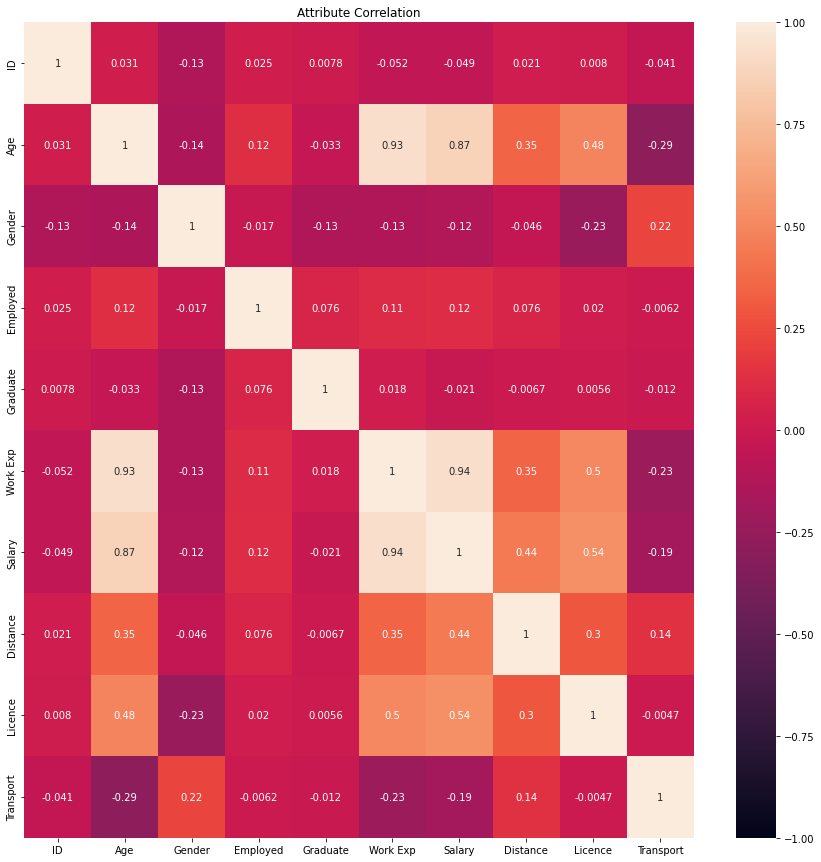

In [22]:
plt.figure(figsize=(15,15))
sns.heatmap(df_train.corr(), vmin=-1, vmax=1, annot=True)
plt.title('Attribute Correlation')
plt.show()

In [23]:
# Disable this line as it doesn't increase model's performance
# df_train = df_train[['Age', 'Gender', 'Work Exp', 'Salary', 'Distance', 'Transport']]
# df_test = df_test[['Age', 'Gender', 'Work Exp', 'Salary', 'Distance']]
# df_validate = df_validate[['Age', 'Gender', 'Work Exp', 'Salary', 'Distance', 'Transport']]

Preparing X_train and y_train for train the model and X_val and y_val for test the model.

In [24]:
# Split df_train into X_train and y_train
X_train = df_train.drop(columns=['Transport'])
y_train = df_train['Transport']

# Split df_validate into X_val and y_val
X_val = df_validate.drop(columns=['Transport'])
y_val = df_validate['Transport']

### 4.0: Helper Function

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# Print classification report
def print_classification_report(name, y_ground_truth, y_prediction):
    print('Classification Report')
    print('-' * 18)
    print(f'Accuracy of {name} classifier:', str(accuracy_score(y_ground_truth,  y_prediction)))
    print(f'Precision of {name} classifier:', str(precision_score(y_ground_truth,  y_prediction, average='macro')))
    print(f'Recall of {name} classifier:', str(recall_score(y_ground_truth,  y_prediction, average='macro')))
    print(f'F1-Macro of {name} classifier:', str(f1_score(y_ground_truth,  y_prediction, average='macro')))
    print('\n')

### 4.1: Decision Tree

In [26]:
from sklearn import tree


# Decision tree using Entropy as its criteriion
clf_en = tree.DecisionTreeClassifier(criterion='entropy')

# Decision tree using Gini Index as its criterion
clf_gini = tree.DecisionTreeClassifier(criterion='gini')

# Train the model
clf_en = clf_en.fit(X_train, y_train)
clf_gini = clf_gini.fit(X_train, y_train)

Tree visualization of clf_en (Decision Tree classifier with Entropy)

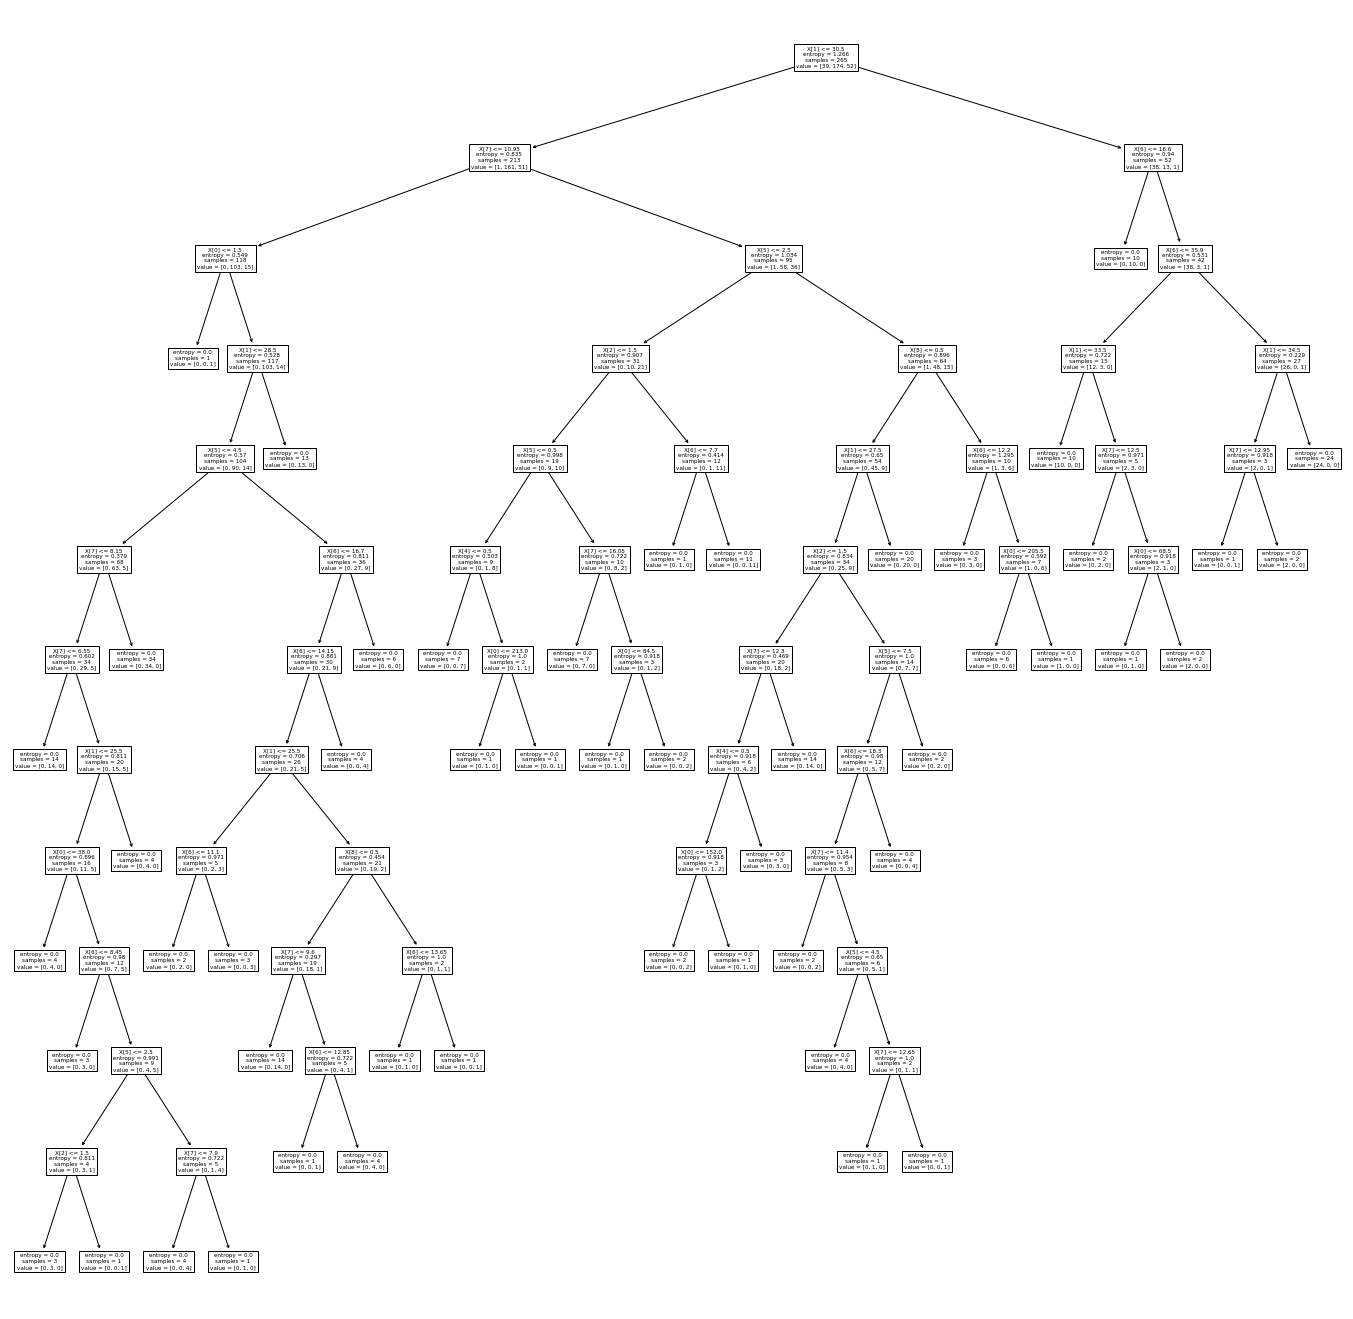

In [27]:
plt.figure(figsize=(24,24))
tree.plot_tree(clf_en)
plt.show()

Tree visualization of clf_gini (Decision Tree classifier with Gini Index)

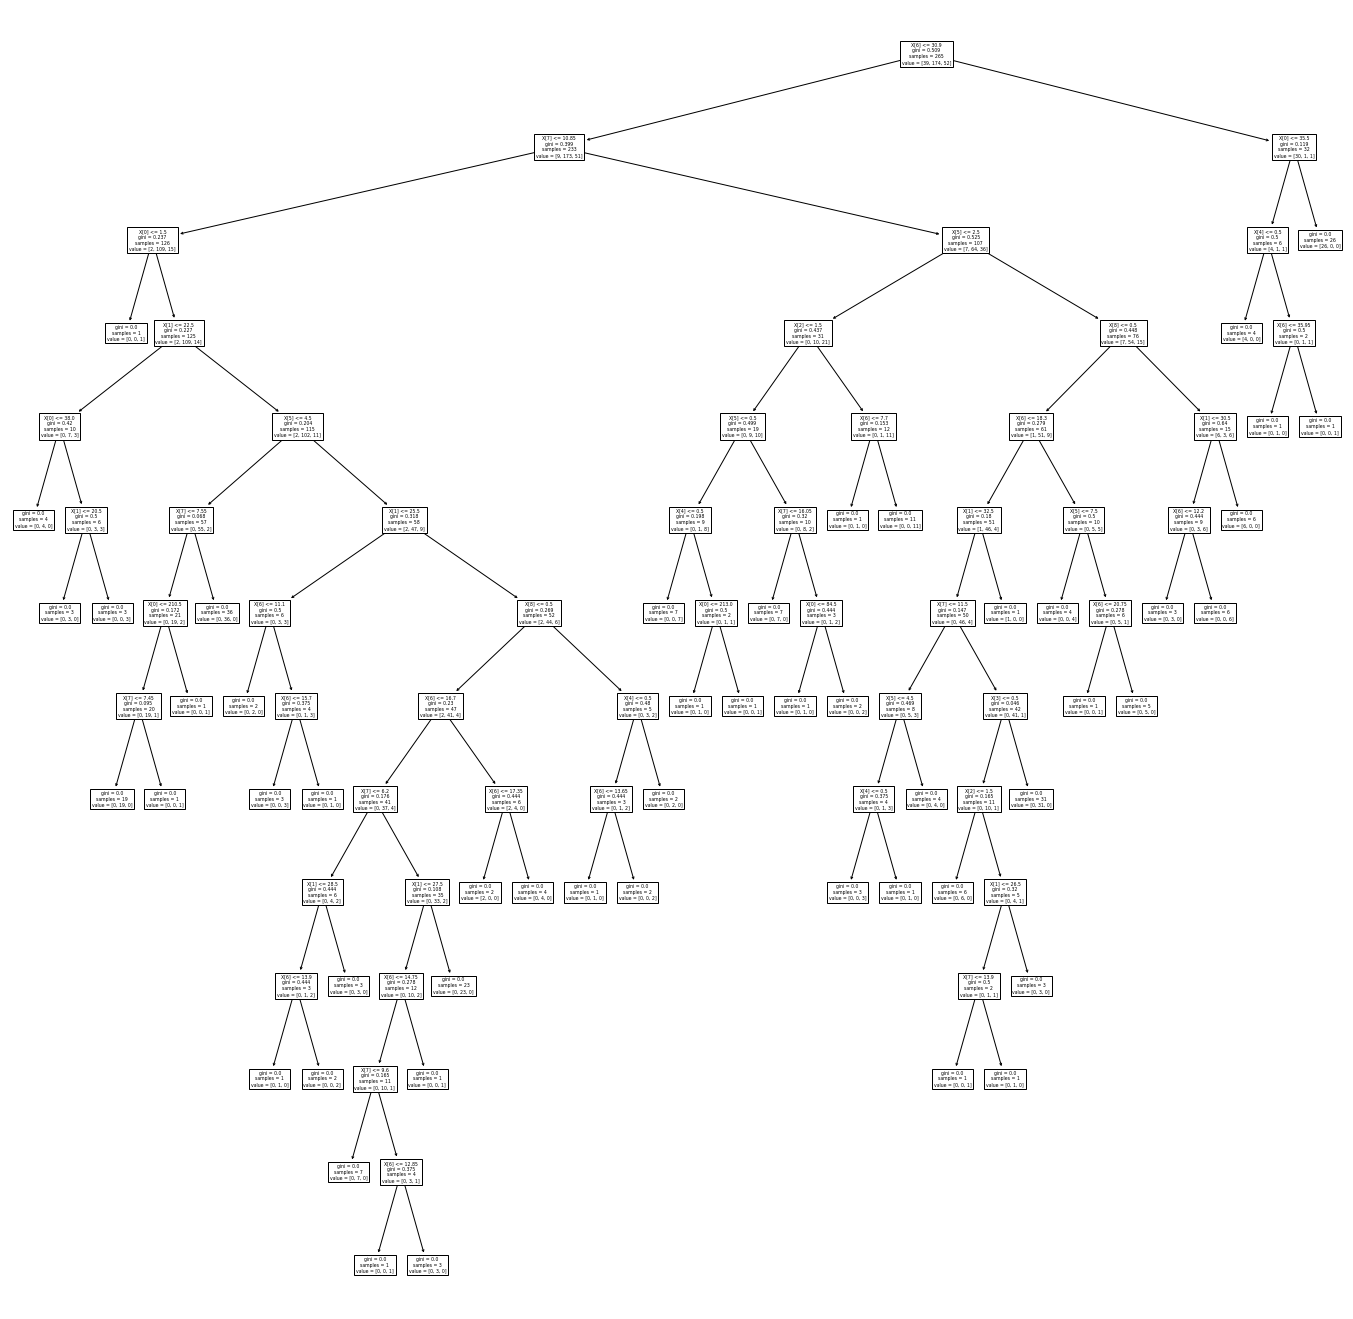

In [28]:
plt.figure(figsize=(24,24))
tree.plot_tree(clf_gini)
plt.show()

### Evaluation

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# Make predictions
y_pred_en = clf_en.predict(X_val)
y_pred_gini = clf_gini.predict(X_val)

# Print classification report
print_classification_report('DecisionTree with Entropy', y_val, y_pred_en)
print_classification_report('DecisionTree with Gini Index', y_val, y_pred_gini)

Classification Report
------------------
Accuracy of DecisionTree with Entropy classifier: 0.8089887640449438
Precision of DecisionTree with Entropy classifier: 0.7386813808715337
Recall of DecisionTree with Entropy classifier: 0.7612179487179488
F1-Macro of DecisionTree with Entropy classifier: 0.7482377202849643


Classification Report
------------------
Accuracy of DecisionTree with Gini Index classifier: 0.8089887640449438
Precision of DecisionTree with Gini Index classifier: 0.7456751422268665
Recall of DecisionTree with Gini Index classifier: 0.8134615384615383
F1-Macro of DecisionTree with Gini Index classifier: 0.7722989923397686




### Conclusion

Entropy used the entropy measurement (degree of disorder) of attributes to decide root of the tree.

### 4.2: Logistic Regression

In [30]:
from sklearn.linear_model import LogisticRegression

clf_log_reg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=100)
clf_log_reg = clf_log_reg.fit(X_train, y_train)

/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,


### Evaluation

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# Make predictions
y_pred_log_reg = clf_log_reg.predict(X_val)

# Print classification report
print_classification_report('Logistic Regression', y_val, y_pred_log_reg)

Classification Report
------------------
Accuracy of Logistic Regression classifier: 0.7640449438202247
Precision of Logistic Regression classifier: 0.6545454545454547
Recall of Logistic Regression classifier: 0.5419871794871794
F1-Macro of Logistic Regression classifier: 0.5594008495416946




### Hyperparameter

In [32]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV


penalty = ['l1', 'l2']
C = np.logspace(-4,4,20)

hyperparameters = dict(penalty=penalty, C=C)

# defining parameter range 
# logreg_grid = GridSearchCV(LogisticRegression(), hyperparameters, cv=5)

# fitting the model for grid search
# logreg_grid = logreg_grid.fit(X_train, y_train)

### 4.3: SVM

In [33]:
from sklearn import svm


# Train SVM
clf_svm = svm.SVC(decision_function_shape='ovo')
clf_svm = clf_svm.fit(X_train, y_train)

### Evaluation

In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# Make predictions
y_pred_svm = clf_svm.predict(X_val)

# Print classification report
print_classification_report('SVM', y_val, y_pred_svm)

Classification Report
------------------
Accuracy of SVM classifier: 0.7640449438202247
Precision of SVM classifier: 0.5206349206349207
Recall of SVM classifier: 0.4948717948717949
F1-Macro of SVM classifier: 0.4914816726897264




/opt/conda/lib/python3.7/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


### Hyperparameter

In [35]:
from sklearn.model_selection import GridSearchCV


# defining parameter range
param_grid = {'C': [0.1, 1, 10, 100, 1000], 
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
              'kernel': ['rbf']} 
  
grid = GridSearchCV(svm.SVC(), param_grid, refit=True, verbose=3)

# fitting the model for grid search
grid = grid.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.642 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.660 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.660 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.660 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.660 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.642 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.660 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.660 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.660 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.660 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.642 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

In [36]:
# print best parameter after tuning
print(grid.best_params_)
  
# print how our model looks after hyper-parameter tuning
print(grid.best_estimator_)

{'C': 1, 'gamma': 0.0001, 'kernel': 'rbf'}
SVC(C=1, gamma=0.0001)


In [37]:
# Make predictions
grid_predictions = grid.predict(X_val)

# Print classification report
print_classification_report('SVM', y_val, y_pred_svm)
print_classification_report('Hypertunned SVM', y_val, grid_predictions)

Classification Report
------------------
Accuracy of SVM classifier: 0.7640449438202247
Precision of SVM classifier: 0.5206349206349207
Recall of SVM classifier: 0.4948717948717949
F1-Macro of SVM classifier: 0.4914816726897264


Classification Report
------------------
Accuracy of Hypertunned SVM classifier: 0.7640449438202247
Precision of Hypertunned SVM classifier: 0.5206349206349207
Recall of Hypertunned SVM classifier: 0.4948717948717949
F1-Macro of Hypertunned SVM classifier: 0.4914816726897264




/opt/conda/lib/python3.7/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.7/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


### 4.4: Gradient Boosting

In [38]:
from sklearn.ensemble import GradientBoostingClassifier


clf_gb = GradientBoostingClassifier()
clf_gb = clf_gb.fit(X_train, y_train)

# Make predictions
y_pred_gb = clf_gb.predict(X_val)

# Print classification report
print_classification_report('Gradient Boosting', y_val, y_pred_gb)

Classification Report
------------------
Accuracy of Gradient Boosting classifier: 0.8314606741573034
Precision of Gradient Boosting classifier: 0.7557692307692307
Recall of Gradient Boosting classifier: 0.7557692307692307
F1-Macro of Gradient Boosting classifier: 0.7557692307692307




## Step 5: Submit Result
___

In [39]:
# Select best model.
# ---
# I use DecisionTree classifier with Gini Index as the best model so far due to limited amount of time given by the assistant.
# Please if you want any quiz make sure the time given to the participants is sufficient :)
# Thank you


clf_best = clf_gb

In [40]:
# Confusion matrix

from sklearn.metrics import confusion_matrix


print('Confusion Matrix')
print('-' * 15)
print(confusion_matrix(y_val, y_pred_gini))

Confusion Matrix
---------------
[[ 7  1  0]
 [ 2 53 10]
 [ 0  4 12]]


In [41]:
# Make predictions from the best model
y_submission = clf_best.predict(df_test)

# Reverse dict for 'Transport' attribute
dict_reverse = {y: x for x, y in dict_transport.items()}

# Convert y_submission value based on its dictionary
result = pd.DataFrame(y_submission, columns=['Transport'])
result = result['Transport'].apply(lambda x: dict_reverse[x])
result.to_csv("submission.csv", index_label = ['ID'])